In [96]:
import yfinance as yf
import pandas as pd
import ssl
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import io
# descargo datos desde 2018 para coincidirlo con el indice F&G 
btc = yf.download("BTC-USD", start="2018-02-01", auto_adjust=False)
ssl._create_default_https_context = ssl._create_unverified_context

# reseteo el indice, dejo de tener date como indice y pasa a ser columna
btc.reset_index(inplace=True)
null =btc.isnull().sum().values
# Filtro solo las columnas necesarias
btc = btc[["Date", "Close", "Open","High", "Low", "Volume"]]
# guardo csv base
btc.to_csv("../Data/btc.csv", index=False)




[*********************100%***********************]  1 of 1 completed


In [78]:
btc.tail() ## Inspecciono las ultimas filas del DF para corroborrar que las columnas esten bien

Price,Date,Close,Open,High,Low,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
3122,2026-08-20,73032.757812,69268.250000,73369.804688,68867.531250,55444322363
3123,2026-08-21,78335.187500,73031.085938,79463.710938,73011.414062,74478039014
3124,2026-08-22,77083.414062,78332.554688,78801.148438,76526.710938,42131959963
3125,2026-08-23,77755.265625,77082.843750,78036.867188,75624.945312,31158396908
3126,2026-08-24,78930.882812,77727.617188,79891.304688,76838.726562,57091620864


In [79]:
#Revisando DataSet
btc.describe()

Price,Date,Close,Open,High,Low,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3127,3127.000000,3127.000000,3127.000000,3127.000000,3.127000e+03
mean,2022-05-14 00:00:00,40133.403435,40112.688172,40885.152031,39293.249236,3.079157e+10
min,2018-02-01 00:00:00,3236.761719,3236.274658,3275.377930,3191.303467,2.923670e+09
25%,2020-03-23 12:00:00,9758.411621,9758.768555,9957.440430,9581.794434,1.606121e+10
50%,2022-05-14 00:00:00,30271.130859,30249.626953,30636.029297,29652.705078,2.688255e+10
75%,2024-07-03 12:00:00,63402.302734,63399.447266,64388.259766,62286.783203,4.036237e+10
max,2026-08-24 00:00:00,124752.531250,124752.140625,126198.070312,123196.046875,3.509679e+11
std,NaN,32450.023992,32447.480546,32963.601880,31891.353442,2.169376e+10


# Analisis Variables

**Date:** Fecha - Se ve que el valor para partimos es 2018-02-01 hasta la fecha de hoy (2026-08-23)

**Close:** El precio de cierre del Bitcoin.

**High:** El precio máximo que alcanzó el Bitcoin durante ese período de tiempo.

**Low:** El precio mínimo que registró el Bitcoin durante ese período.

**Open:** El precio de apertura del Bitcoin al inicio del período.

Las columnas de Close,High,Low y Open tienen una desviación estandar altasima, eso nos da un indicio de que los valores tienen una volatilidad enorme en este periodo (2018-02-01 a 2026-08-23 )

**Volume:** El volumen total de transacciones (la cantidad de BTC vendida y comprada) durante ese período.

# Observaciones

La media ($40120.89) es mayor que la mediana **($30260.13)**, esto nos da como indicio que la distribución está sestaga hacia derecha.
El *rango interquartilico (Q3 - Q1)* =>  $63400,34 - $9758.19  = $53642.15 -> Esto refleja una brecha de más de $53000 en el 50% central, lo cual nos indica lo volatil que es el BTC.


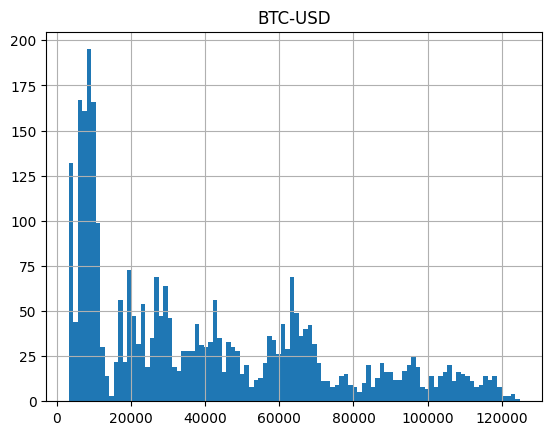

In [80]:
#Histograma Precio Ciere Bitcoin
hist = btc.Close.hist(bins=100)


<Axes: ylabel='Density'>

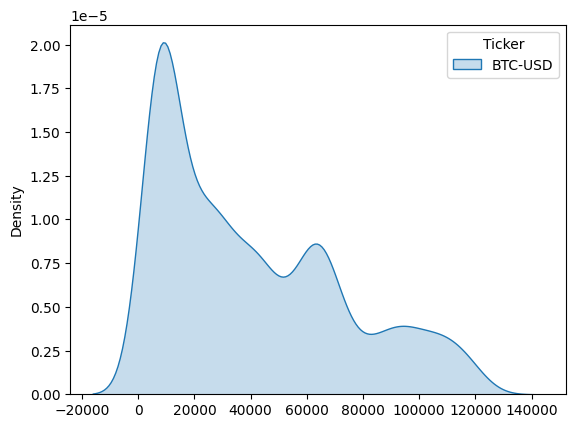

In [81]:
sns.kdeplot(btc['Close'],fill=True)

<Figure size 800x1000 with 0 Axes>

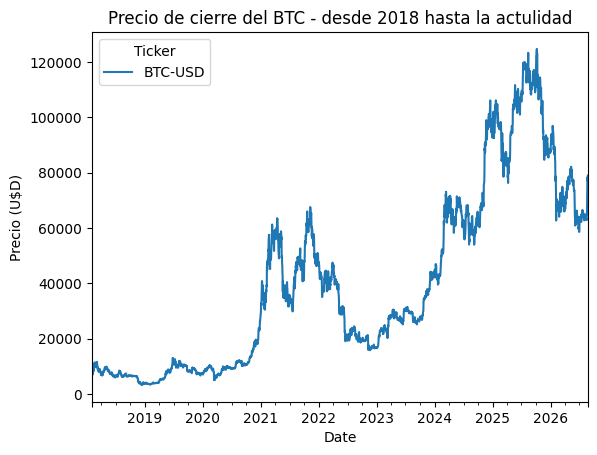

In [83]:
#Precio historico del btc (Close)
plt.figure(figsize=(8,10))
btc.set_index('Date')['Close'].plot(title='Precio de cierre del BTC - desde 2018 hasta la actulidad')
plt.ylabel('Precio (U$D)')
plt.show()

In [84]:
#Indice Fear and Greed -- Mide el miedo del mercado 

url = "https://api.alternative.me/fng/?date_format=%2701%2F01%2F2018%27&format=csv&limit=50000"
response = requests.get(url)

if response.status_code == 200:
    content = response.content.decode('utf-8')
    start = content.find("fng_value")
    csv_data = content[start:]
    # Leer el CSV desde el string
    df = pd.read_csv(io.StringIO(csv_data))
    # Renombrar columnas
    df = df.rename(columns={
        'fng_value': 'date',
        'fng_classification': 'fng_value',
        'date': 'fng_classification'
    })
    # Guardar el nuevo CSV
    df = df.iloc[:-5]
    df.to_csv("../Data/fear_greed.csv", index=False)
    print(df.head(20)) #Muestro los ultimos 20 datos 
else:
    print("Error:", response.status_code)

          date  fng_value fng_classification
0   24-08-2026       73.0              Greed
1   23-08-2026       66.0              Greed
2   22-08-2026       71.0              Greed
3   21-08-2026       72.0              Greed
4   20-08-2026       62.0              Greed
5   19-08-2026       46.0               Fear
6   18-08-2026       41.0               Fear
7   17-08-2026       31.0               Fear
8   16-08-2026       34.0               Fear
9   15-08-2026       34.0               Fear
10  14-08-2026       29.0               Fear
11  13-08-2026       29.0               Fear
12  12-08-2026       27.0               Fear
13  11-08-2026       29.0               Fear
14  10-08-2026       30.0               Fear
15  09-08-2026       31.0               Fear
16  08-08-2026       30.0               Fear
17  07-08-2026       29.0               Fear
18  06-08-2026       25.0       Extreme Fear
19  05-08-2026       27.0               Fear


In [85]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3123 non-null   object 
 1   fng_value           3123 non-null   float64
 2   fng_classification  3123 non-null   object 
dtypes: float64(1), object(2)
memory usage: 73.3+ KB


In [86]:
df.describe()
#3126 - Datos Btc

,fng_value
count,3123.000000
mean,45.396734
std,22.044154
min,5.000000
25%,26.000000
50%,44.000000
75%,64.000000
max,95.000000


In [121]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')  # ajustar el formato según cómo venga el string
df = df.set_index('date')

KeyError: 'date'

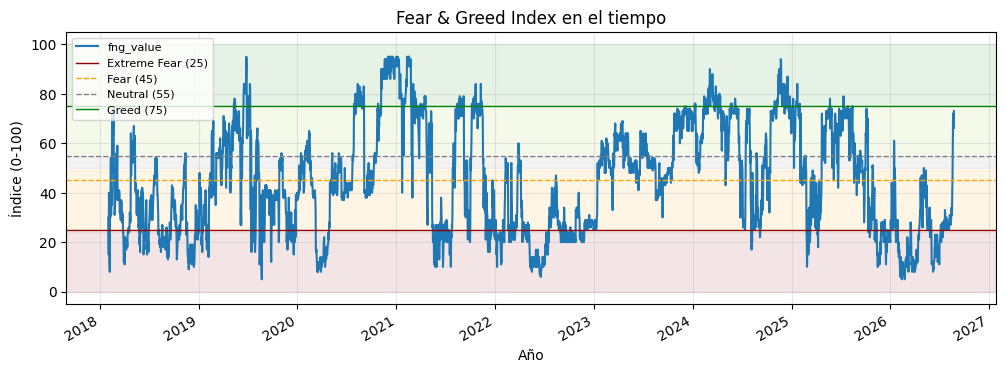

In [122]:
import matplotlib.dates as mdates
df = df.sort_index()
ax = df['fng_value'].plot(figsize=(12,4), title='Fear & Greed Index en el tiempo',x_compat = True)
ax.set_xlabel('Año')
ax.set_ylabel('Índice (0-100)')
ax.grid(True, alpha=0.3)

# Mostrar solo el año en el eje X, una marca por año
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Umbrales de clasificación
ax.axhline(25, color='darkred', linestyle='-', linewidth=1, label='Extreme Fear (25)')
ax.axhline(45, color='orange', linestyle='--', linewidth=1, label='Fear (45)')
ax.axhline(55, color='gray', linestyle='--', linewidth=1, label='Neutral (55)')
ax.axhline(75, color='green', linestyle='-', linewidth=1, label='Greed (75)')

# Zonas sombreadas por clasificación
ax.axhspan(0, 24, color='darkred', alpha=0.1)     # Extreme Fear
ax.axhspan(25, 49, color='orange', alpha=0.1)     # Fear
ax.axhspan(50, 55, color='gray', alpha=0.1)       # Neutral
ax.axhspan(56, 74, color='yellowgreen', alpha=0.1) # Greed
ax.axhspan(75, 100, color='green', alpha=0.1)     # Extreme Greed

ax.legend(loc='upper left', fontsize=8)
plt.show()

<Axes: ylabel='count'>

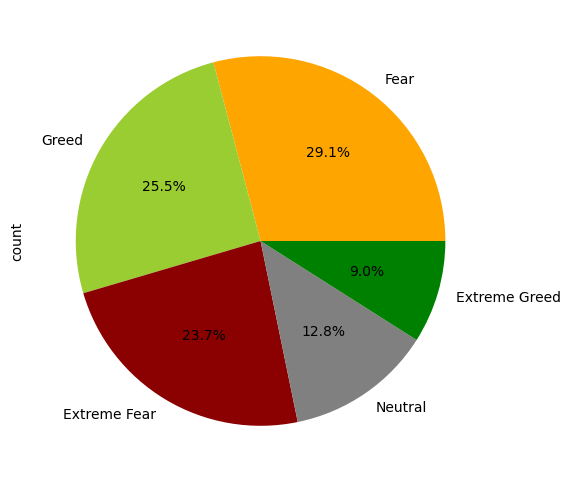

In [120]:
#Grafico de tort mostrando los datos por etiqueta.
counts = df['fng_classification'].value_counts()
colores = {
    'Extreme Fear': 'darkred',
    'Fear': 'orange',
    'Neutral': 'gray',
    'Greed': 'yellowgreen',
    'Extreme Greed': 'green'
}
counts.plot.pie(
    autopct='%1.1f%%',
    colors=[colores[c] for c in counts.index],
    figsize=(6,6)
)

## Observaciones
De los datos historicos del indice Fear & Greed nos indica que:
34,5% de los datos fueron sentimientos positivos del mercado.
52,8 % Hay un temor por el activo.
Y el restante 12,8% es un sentimiento de indiferencia.
Esto nos indica que el "Miedo" es el factor predominante en el dataset